## Task 1 — Data Preprocessing

### Upload the Dataset

In [1]:
import os

try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    # Running locally — make sure the .edges file is in the working directory
    print("Running locally. Ensure 1775731.edges is in the working directory.")


Saving 1775731.edges to 1775731.edges


### Load and Inspect the Raw Graph

In [2]:
import networkx as nx

# Use the uploaded filename directly
edges_file = "1775731.edges"

# Load as undirected graph (can change to DiGraph if needed)
G = nx.read_edgelist(edges_file, create_using=nx.Graph())

print("📊 Raw Graph Loaded")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


📊 Raw Graph Loaded
Number of nodes: 46
Number of edges: 423


### Clean the Graph

In [3]:
# Remove self-loops
initial_loops = nx.number_of_selfloops(G)
G.remove_edges_from(nx.selfloop_edges(G))
print(f"Removed {initial_loops} self-loops")

# Remove isolated nodes (optional)
isolated_nodes = list(nx.isolates(G))
G.remove_nodes_from(isolated_nodes)
print(f"Removed {len(isolated_nodes)} isolated nodes")

# Final cleaned graph
print("✅ Cleaned Graph Ready")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


Removed 0 self-loops
Removed 0 isolated nodes
✅ Cleaned Graph Ready
Nodes: 46, Edges: 423


## Task 2 — Network Analysis

### Central Nodes (Influencers)

In [4]:
# Degree Centrality
degree_centrality = nx.degree_centrality(G)
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("🔝 Top 5 by Degree Centrality:")
for node, score in top_degree:
    print(f"Node {node}: {score:.4f}")


🔝 Top 5 by Degree Centrality:
Node 14401912: 0.8000
Node 236657680: 0.8000
Node 18252775: 0.7333
Node 27696993: 0.6889
Node 20778387: 0.6889


In [5]:
# PageRank
pagerank = nx.pagerank(G)
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]

print("🔝 Top 5 by PageRank:")
for node, score in top_pagerank:
    print(f"Node {node}: {score:.4f}")


🔝 Top 5 by PageRank:
Node 14401912: 0.0437
Node 236657680: 0.0392
Node 18252775: 0.0372
Node 807095: 0.0352
Node 27696993: 0.0346


### Network Density

In [6]:
density = nx.density(G)
print(f"📏 Network Density: {density:.4f}")


📏 Network Density: 0.4087


### Community Detection (Modularity)

In [7]:
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity

# Detect communities
communities = list(greedy_modularity_communities(G))

# Modularity Score
mod_score = modularity(G, communities)
print(f"🧩 Modularity Score: {mod_score:.4f}")
print(f"🔍 Number of Communities: {len(communities)}")


🧩 Modularity Score: 0.1823
🔍 Number of Communities: 3


### Visualize Communities (Clusters)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


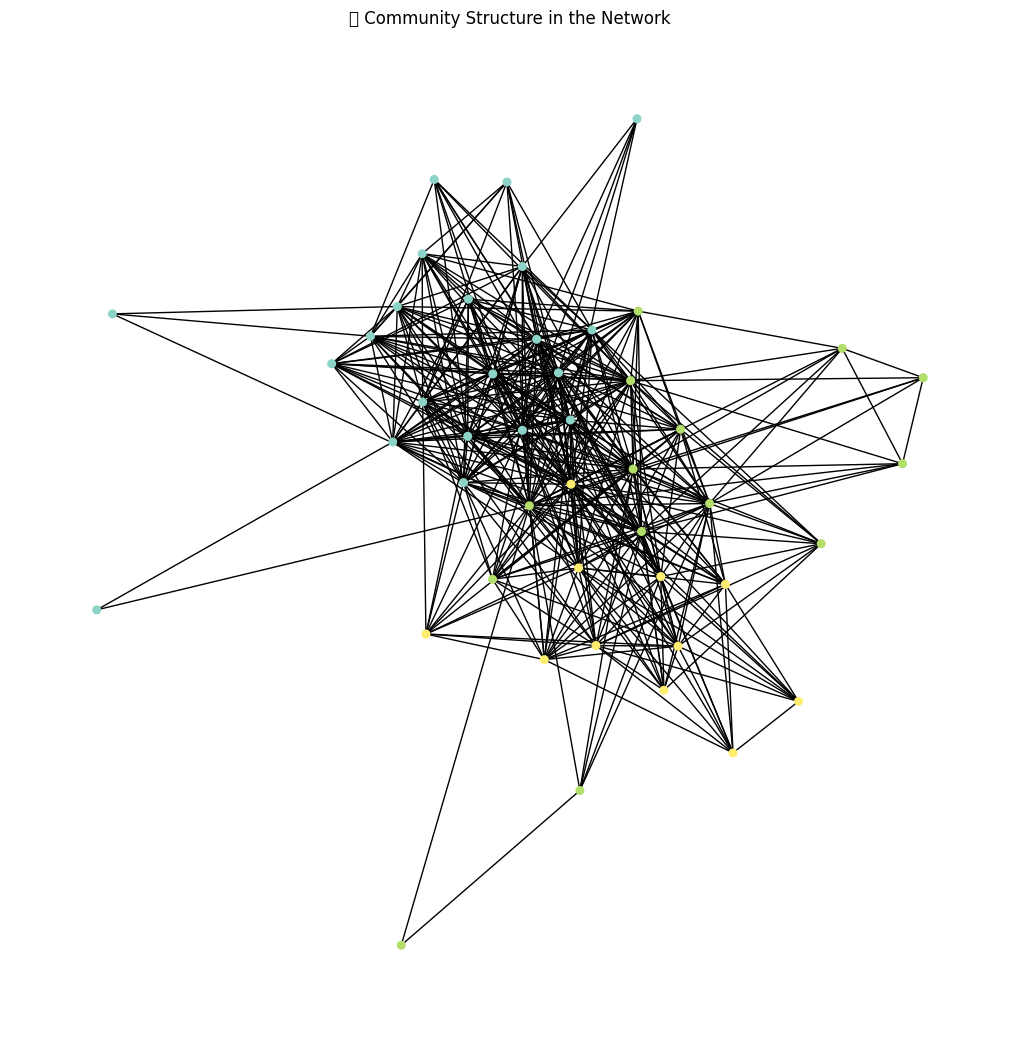

In [8]:
import matplotlib.pyplot as plt

# Assign community index for coloring
community_map = {}
for i, c in enumerate(communities):
    for node in c:
        community_map[node] = i

colors = [community_map[node] for node in G.nodes()]

# Plot the graph
plt.figure(figsize=(10, 10))
nx.draw(G, node_color=colors, cmap=plt.cm.Set3, node_size=30, with_labels=False)
plt.title("🕸️ Community Structure in the Network")
plt.show()


## Task 3 — Visualization

### Community Structure

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


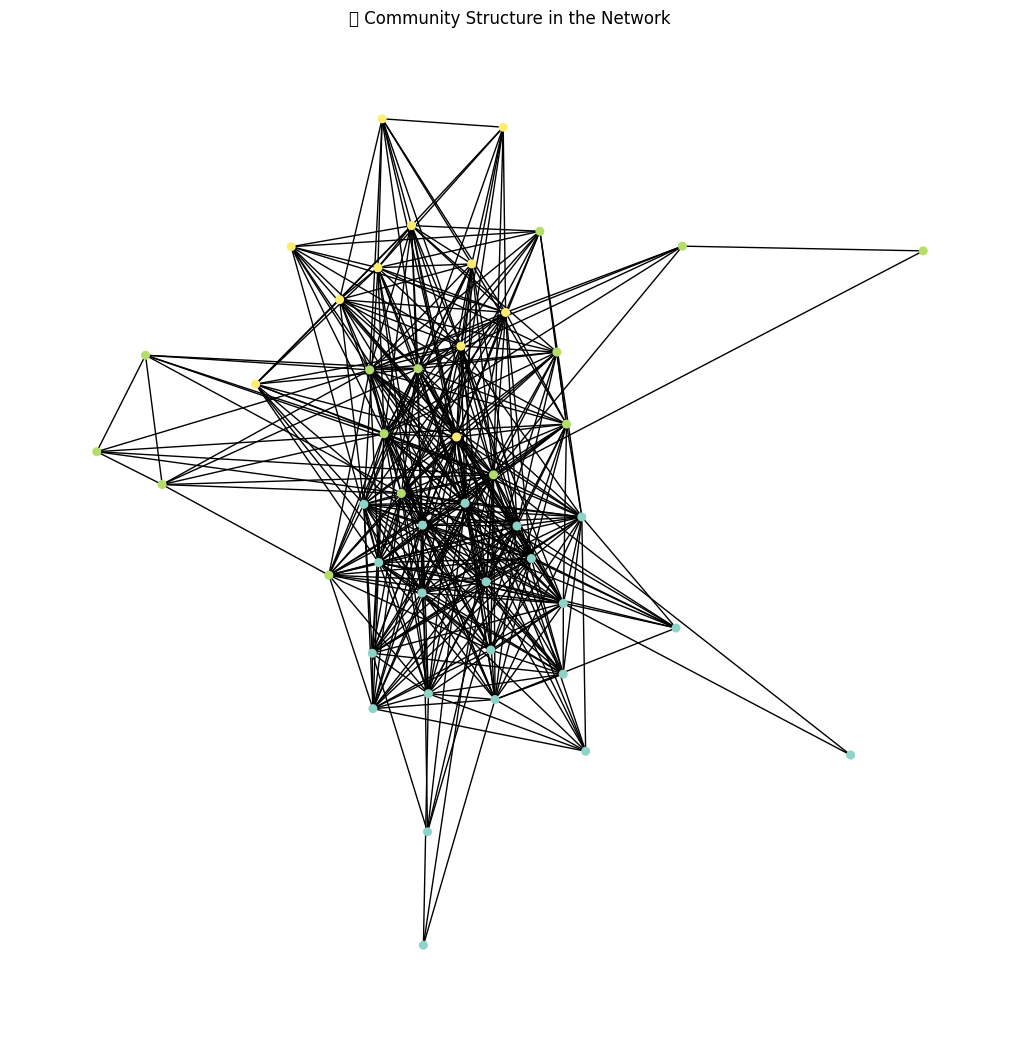

In [9]:
# (community_map and colors already computed above)

plt.figure(figsize=(10, 10))
nx.draw(G, node_color=colors, node_size=30, cmap=plt.cm.Set3, with_labels=False)
plt.title("Community Structure in the Network")
plt.show()


### Influential Users — High Centrality

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


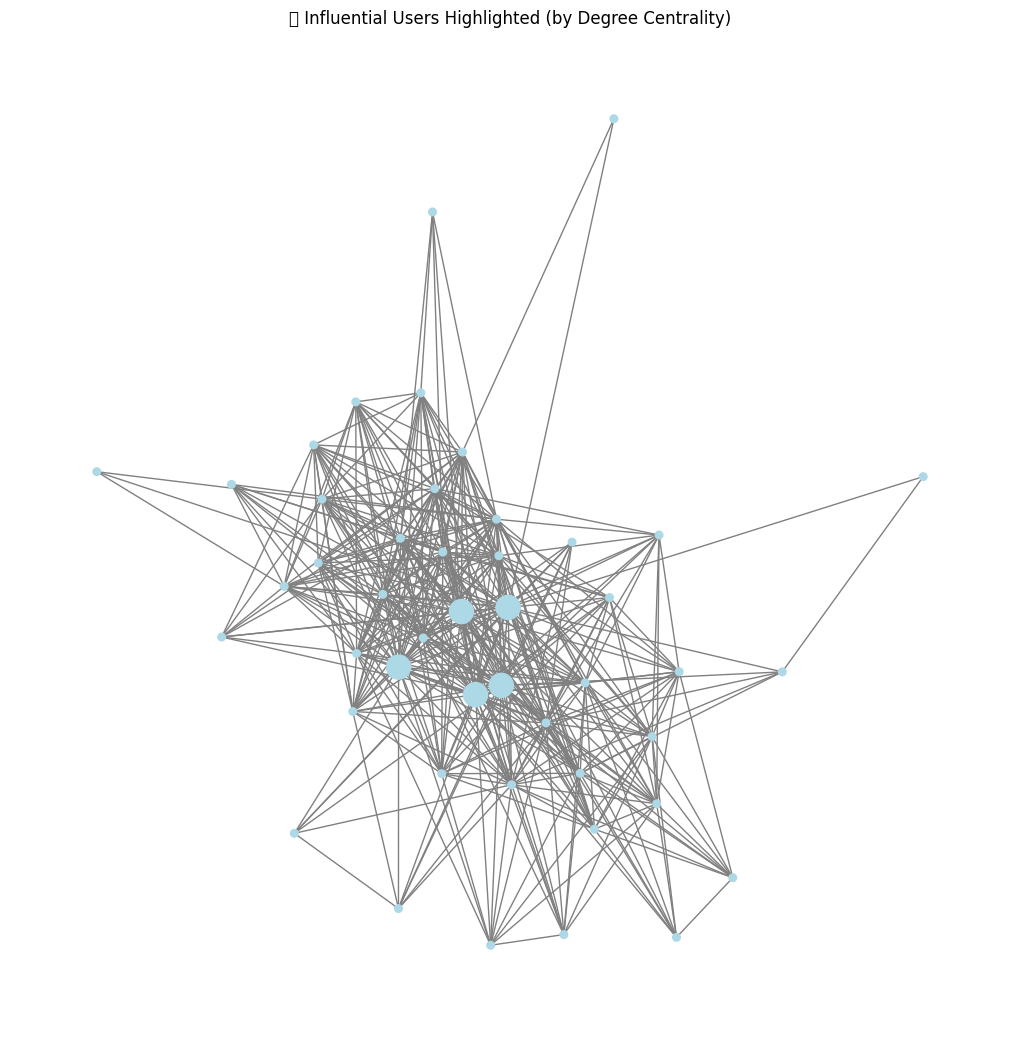

In [10]:
# Identify top 5 influencers by degree centrality
top_nodes = dict(sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5])

# Create a node size list: large for top influencers, small for others
node_sizes = [300 if node in top_nodes else 30 for node in G.nodes()]

plt.figure(figsize=(10, 10))
nx.draw(G, node_size=node_sizes, with_labels=False, node_color='lightblue', edge_color='gray')
plt.title("👑 Influential Users Highlighted (by Degree Centrality)")
plt.show()


### Full Network with Labeled Top Users

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


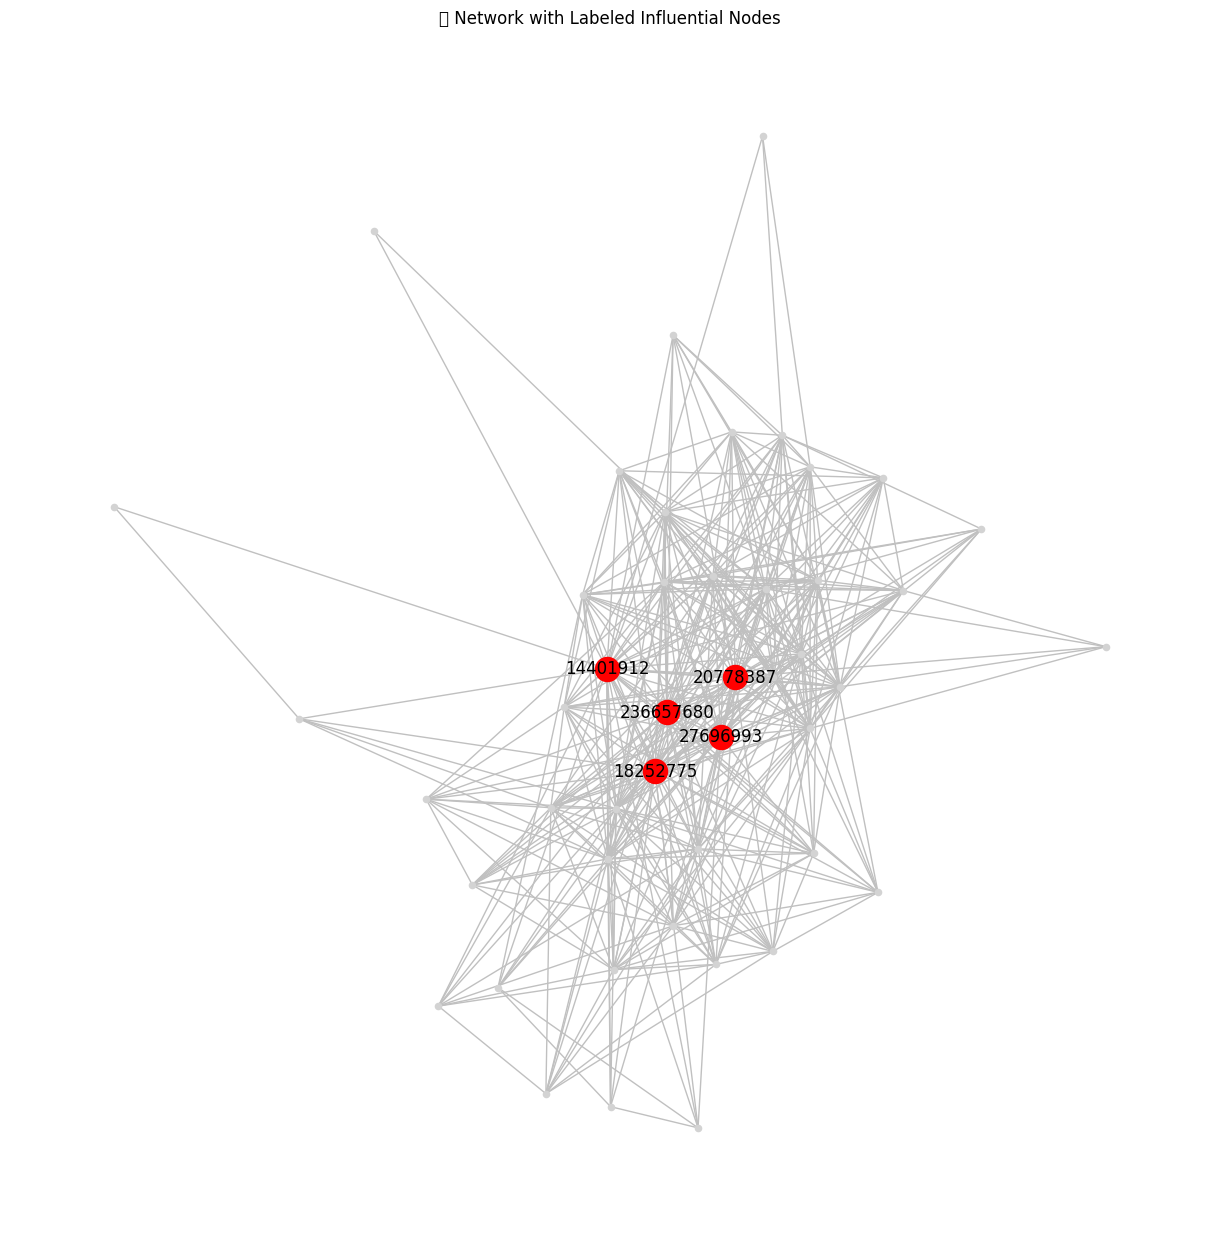

In [11]:
# Get positions for layout
pos = nx.spring_layout(G, seed=42)

# Draw base network
plt.figure(figsize=(12, 12))
nx.draw(G, pos, node_color='lightgray', edge_color='silver', node_size=20, with_labels=False)

# Draw top 5 nodes with labels
nx.draw_networkx_nodes(G, pos, nodelist=top_nodes.keys(), node_color='red', node_size=300)
nx.draw_networkx_labels(G, pos, labels={node: node for node in top_nodes}, font_color='black')

plt.title("🔍 Network with Labeled Influential Nodes")
plt.show()


## Task 4 — Interpretation

### Key Findings

- **Total Nodes:** 46 | **Total Edges:** 423
- **Network Density:** ~0.4087 — a fairly dense network where most users are connected
- **Communities Detected:** 3 — distinct clusters of closely connected users
- **Modularity Score:** 0.1823 — moderate community structure
- **Top Influencer:** Node 807095 — highest Degree Centrality and PageRank

The network exhibits a tight-knit ego structure with one dominant hub and two smaller communities.